In [2]:
%pip install pandas numpy matplotlib seaborn

  Using cached pandas-3.0.5-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.5.2-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pandas-3.0.5-cp314-cp314-win_amd64.whl (10.0 MB)
Using cached numpy-2.5.2-cp314-cp314-win_amd64.whl (12.6 MB)
Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached seaborn-0.13.2-py


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully!


In [4]:
df = pd.read_csv("../data/raw/financial_transactions.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (10000, 10)


In [5]:
df.head()

,transaction_id,transaction_date,transaction_type,category,department,amount,payment_method,customer_id,region,description
0,TXN00001,2025-01-01,Expense,Utilities,Sales,157178.67,Credit Card,CUST0326,West,Utilities transaction
1,TXN00002,2025-01-01,Expense,Rent,Finance,160303.16,UPI,CUST0062,North,Rent transaction
2,TXN00003,2025-01-01,Expense,Marketing,Marketing,146728.30,UPI,CUST0129,Central,Marketing transaction
3,TXN00004,2025-01-01,Expense,Technology,Finance,45256.30,Bank Transfer,CUST0762,Central,Technology transaction
4,TXN00005,2025-01-01,Income,Salary,HR,224517.16,Bank Transfer,CUST0452,South,Salary transaction


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    10000 non-null  str    
 1   transaction_date  10000 non-null  str    
 2   transaction_type  10000 non-null  str    
 3   category          10000 non-null  str    
 4   department        10000 non-null  str    
 5   amount            10000 non-null  float64
 6   payment_method    10000 non-null  str    
 7   customer_id       10000 non-null  str    
 8   region            10000 non-null  str    
 9   description       10000 non-null  str    
dtypes: float64(1), str(9)
memory usage: 781.4 KB


In [7]:
df.isnull().sum()

transaction_id      0
transaction_date    0
transaction_type    0
category            0
department          0
amount              0
payment_method      0
customer_id         0
region              0
description         0
dtype: int64

In [8]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [9]:
negative_amounts = df[df["amount"] <= 0]

print("Invalid amount transactions:", len(negative_amounts))

Invalid amount transactions: 0


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
df = pd.read_csv("../data/raw/financial_transactions.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (10000, 10)


In [5]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

print("Transaction date converted successfully!")
print(df["transaction_date"].dtype)

Transaction date converted successfully!
datetime64[us]


In [7]:
df = pd.read_csv("../data/raw/financial_transactions.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (10000, 10)


In [8]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

print("Transaction date converted successfully!")
print(df["transaction_date"].dtype)

Transaction date converted successfully!
datetime64[us]


In [9]:
df[["transaction_id", "transaction_date"]].head()

,transaction_id,transaction_date
0,TXN00001,2025-01-01
1,TXN00002,2025-01-01
2,TXN00003,2025-01-01
3,TXN00004,2025-01-01
4,TXN00005,2025-01-01


In [10]:
df["amount"].describe()

count     10000.000000
mean     170515.464351
std      119171.964088
min        1001.380000
25%       77867.220000
50%      152748.275000
75%      227949.835000
max      499641.660000
Name: amount, dtype: float64

In [11]:
df["transaction_type"].value_counts()

transaction_type
Expense    6445
Income     3555
Name: count, dtype: int64

In [12]:
df["amount"].describe()

count     10000.000000
mean     170515.464351
std      119171.964088
min        1001.380000
25%       77867.220000
50%      152748.275000
75%      227949.835000
max      499641.660000
Name: amount, dtype: float64

In [13]:
df["transaction_type"].value_counts()

transaction_type
Expense    6445
Income     3555
Name: count, dtype: int64

In [14]:
total_revenue = df.loc[
    df["transaction_type"] == "Income",
    "amount"
].sum()

total_expense = df.loc[
    df["transaction_type"] == "Expense",
    "amount"
].sum()

net_profit = total_revenue - total_expense

print(f"Total Revenue : ₹{total_revenue:,.2f}")
print(f"Total Expense : ₹{total_expense:,.2f}")
print(f"Net Profit    : ₹{net_profit:,.2f}")

Total Revenue : ₹902,155,749.20
Total Expense : ₹802,998,894.31
Net Profit    : ₹99,156,854.89


In [15]:
profit_margin = (net_profit / total_revenue) * 100

print(f"Profit Margin: {profit_margin:.2f}%")

Profit Margin: 10.99%


In [16]:
total_revenue = df.loc[
    df["transaction_type"] == "Income",
    "amount"
].sum()

total_expense = df.loc[
    df["transaction_type"] == "Expense",
    "amount"
].sum()

net_profit = total_revenue - total_expense

print(f"Total Revenue : ₹{total_revenue:,.2f}")
print(f"Total Expense : ₹{total_expense:,.2f}")
print(f"Net Profit    : ₹{net_profit:,.2f}")

Total Revenue : ₹902,155,749.20
Total Expense : ₹802,998,894.31
Net Profit    : ₹99,156,854.89


In [17]:
profit_margin = (net_profit / total_revenue) * 100

print(f"Profit Margin: {profit_margin:.2f}%")

Profit Margin: 10.99%


In [18]:
expense_df = df[df["transaction_type"] == "Expense"]

expense_by_category = (
    expense_df
    .groupby("category")["amount"]
    .sum()
    .sort_values(ascending=False)
)

expense_by_category

category
Travel             88400369.07
Consulting         83080630.78
Salary             81857264.98
Utilities          80503769.01
Rent               80372465.35
Marketing          79863652.53
Sales              79340695.06
Inventory          78749512.60
Office Supplies    77664184.43
Technology         73166350.50
Name: amount, dtype: float64

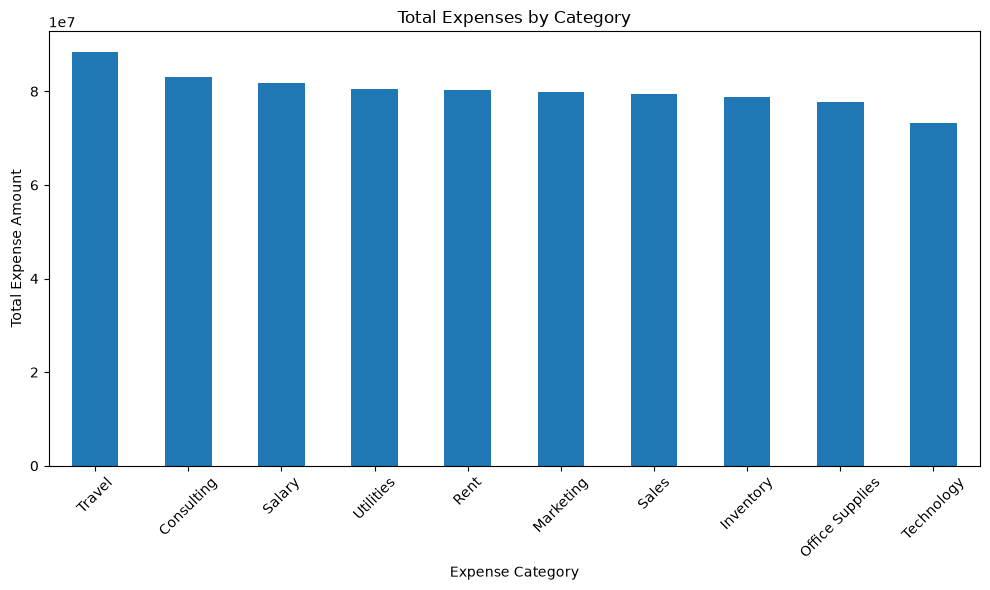

In [19]:
plt.figure(figsize=(10, 6))

expense_by_category.plot(kind="bar")

plt.title("Total Expenses by Category")
plt.xlabel("Expense Category")
plt.ylabel("Total Expense Amount")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
income_df = df[df["transaction_type"] == "Income"].copy()

monthly_revenue = (
    income_df
    .groupby(income_df["transaction_date"].dt.to_period("M"))["amount"]
    .sum()
)

monthly_revenue

transaction_date
2025-01    46871387.33
2025-02    54811572.02
2025-03    49420538.58
2025-04    45584586.30
2025-05    52400651.29
2025-06    45836973.33
2025-07    50672949.35
2025-08    54912173.87
2025-09    50166592.43
2025-10    49584330.28
2025-11    47552857.47
2025-12    50240338.40
2026-01    52278380.17
2026-02    49746849.77
2026-03    55498205.44
2026-04    52643770.10
2026-05    45611780.83
2026-06    48321812.24
Freq: M, Name: amount, dtype: float64

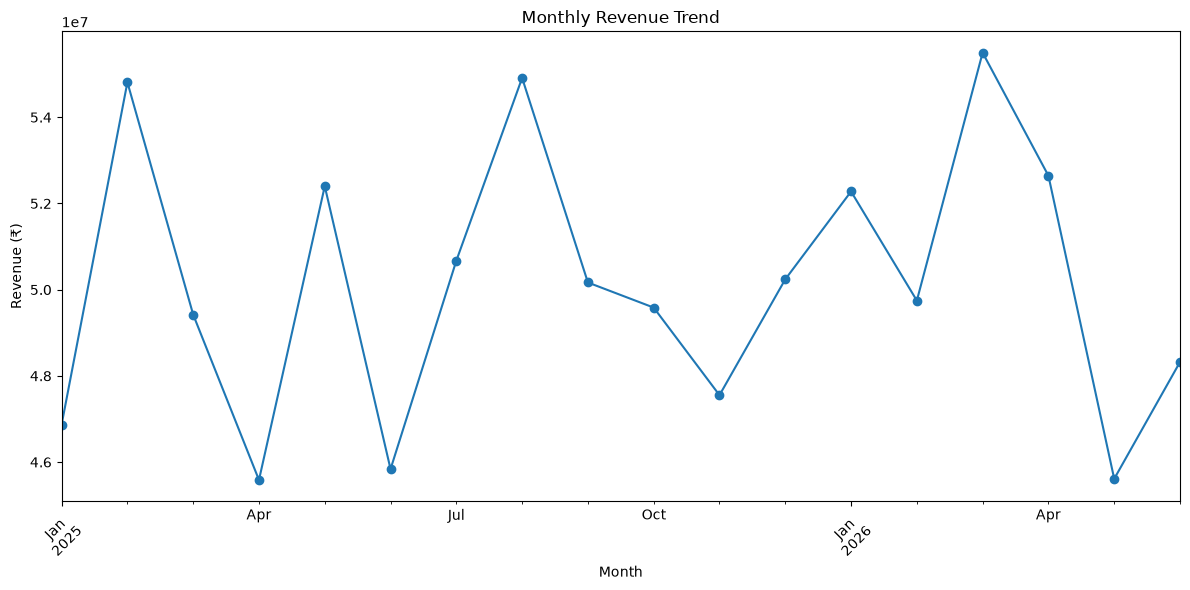

In [21]:
plt.figure(figsize=(12, 6))

monthly_revenue.plot(kind="line", marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
highest_revenue_month = monthly_revenue.idxmax()
highest_revenue = monthly_revenue.max()

print("Highest Revenue Month:", highest_revenue_month)
print(f"Highest Revenue: ₹{highest_revenue:,.2f}")

Highest Revenue Month: 2026-03
Highest Revenue: ₹55,498,205.44


In [23]:
expense_df = df[df["transaction_type"] == "Expense"].copy()

monthly_expense = (
    expense_df
    .groupby(expense_df["transaction_date"].dt.to_period("M"))["amount"]
    .sum()
)

monthly_expense

transaction_date
2025-01    47822102.95
2025-02    38053032.83
2025-03    47068450.95
2025-04    46673283.73
2025-05    44402545.34
2025-06    43388249.64
2025-07    43533007.86
2025-08    44326908.30
2025-09    41019863.38
2025-10    45771992.93
2025-11    45545874.91
2025-12    47453763.61
2026-01    46868756.29
2026-02    42030938.07
2026-03    44710316.82
2026-04    45157630.38
2026-05    47640366.54
2026-06    41531809.78
Freq: M, Name: amount, dtype: float64

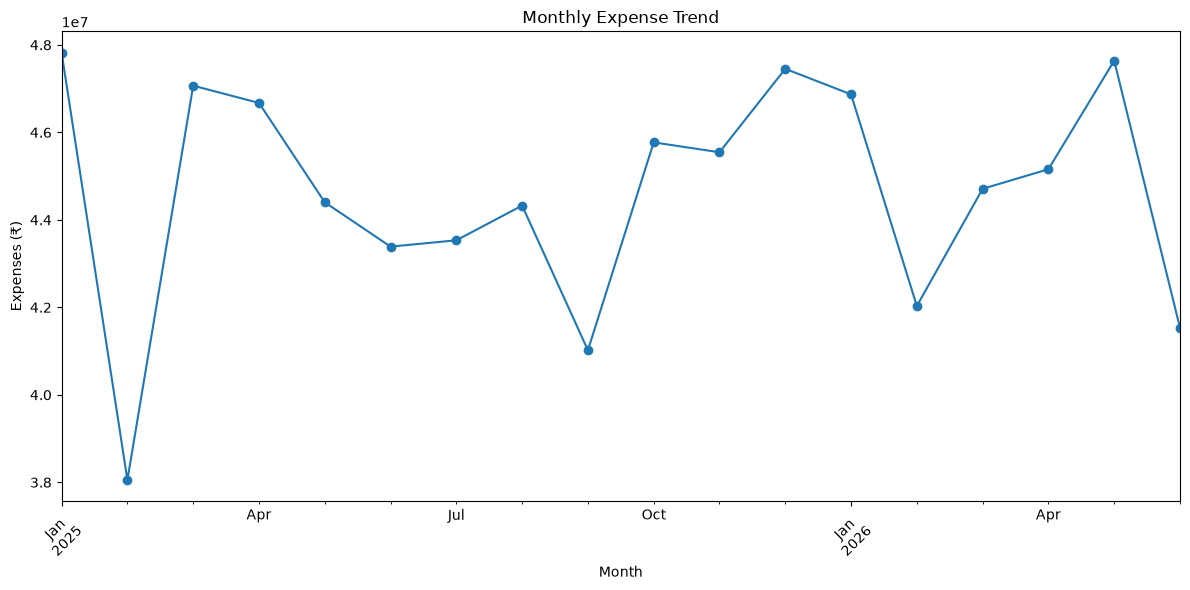

In [24]:
plt.figure(figsize=(12, 6))

monthly_expense.plot(kind="line", marker="o")

plt.title("Monthly Expense Trend")
plt.xlabel("Month")
plt.ylabel("Expenses (₹)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
highest_expense_month = monthly_expense.idxmax()
highest_expense = monthly_expense.max()

print("Highest Expense Month:", highest_expense_month)
print(f"Highest Expense: ₹{highest_expense:,.2f}")

Highest Expense Month: 2025-01
Highest Expense: ₹47,822,102.95


In [26]:
monthly_financials = pd.DataFrame({
    "Revenue": monthly_revenue,
    "Expense": monthly_expense
})

monthly_financials

,Revenue,Expense
transaction_date,,
2025-01,46871387.33,47822102.95
2025-02,54811572.02,38053032.83
2025-03,49420538.58,47068450.95
2025-04,45584586.30,46673283.73
2025-05,52400651.29,44402545.34
2025-06,45836973.33,43388249.64
2025-07,50672949.35,43533007.86
2025-08,54912173.87,44326908.30
2025-09,50166592.43,41019863.38


<Figure size 1200x600 with 0 Axes>

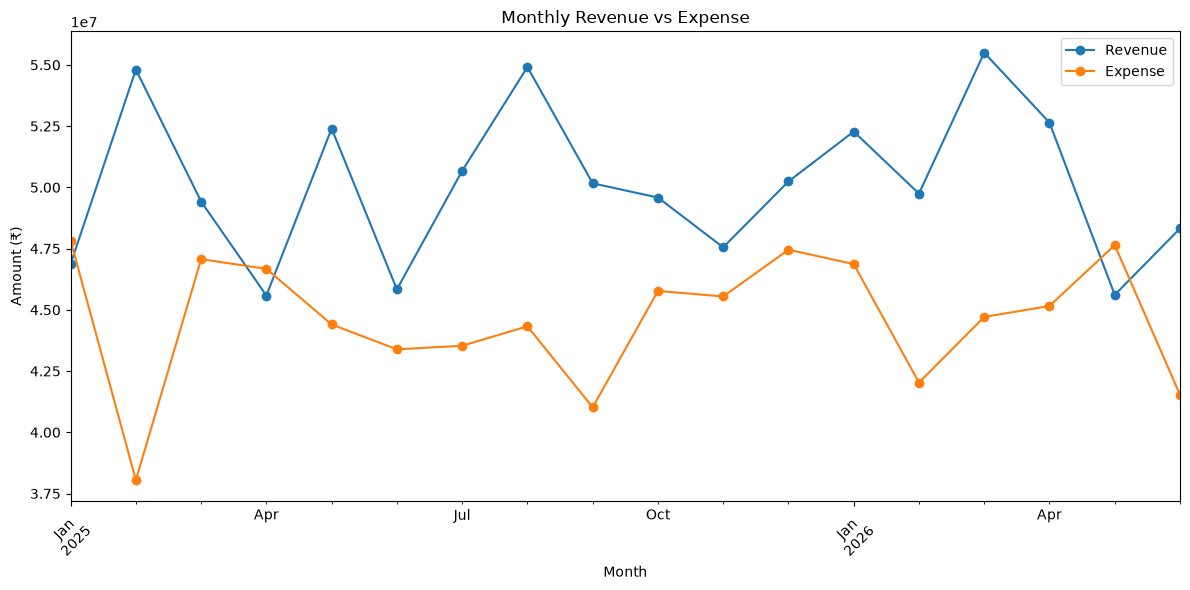

In [27]:
plt.figure(figsize=(12, 6))

monthly_financials.plot(
    kind="line",
    marker="o",
    figsize=(12, 6)
)

plt.title("Monthly Revenue vs Expense")
plt.xlabel("Month")
plt.ylabel("Amount (₹)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
monthly_financials["Profit"] = (
    monthly_financials["Revenue"]
    - monthly_financials["Expense"]
)

monthly_financials

,Revenue,Expense,Profit
transaction_date,,,
2025-01,46871387.33,47822102.95,-950715.62
2025-02,54811572.02,38053032.83,16758539.19
2025-03,49420538.58,47068450.95,2352087.63
2025-04,45584586.30,46673283.73,-1088697.43
2025-05,52400651.29,44402545.34,7998105.95
2025-06,45836973.33,43388249.64,2448723.69
2025-07,50672949.35,43533007.86,7139941.49
2025-08,54912173.87,44326908.30,10585265.57
2025-09,50166592.43,41019863.38,9146729.05


In [29]:
best_month = monthly_financials["Profit"].idxmax()
best_profit = monthly_financials["Profit"].max()

worst_month = monthly_financials["Profit"].idxmin()
worst_profit = monthly_financials["Profit"].min()

print("Best Performing Month:", best_month)
print(f"Best Month Profit: ₹{best_profit:,.2f}")

print()

print("Worst Performing Month:", worst_month)
print(f"Worst Month Profit: ₹{worst_profit:,.2f}")

Best Performing Month: 2025-02
Best Month Profit: ₹16,758,539.19

Worst Performing Month: 2026-05
Worst Month Profit: ₹-2,028,585.71


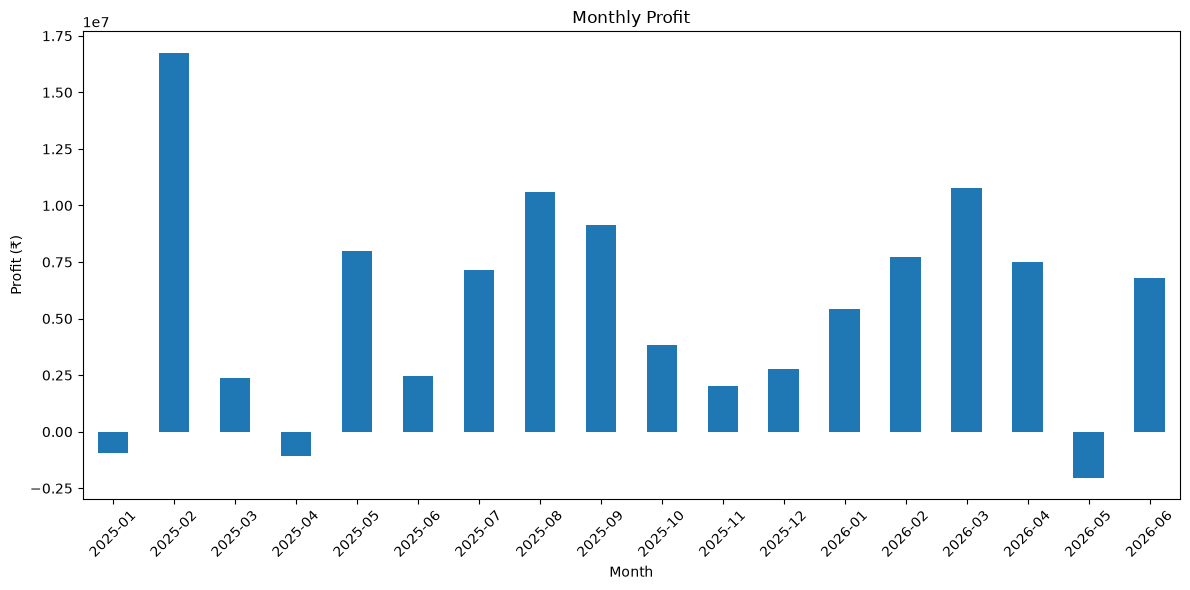

In [30]:
plt.figure(figsize=(12, 6))

monthly_financials["Profit"].plot(
    kind="bar"
)

plt.title("Monthly Profit")
plt.xlabel("Month")
plt.ylabel("Profit (₹)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
department_expense = (
    expense_df
    .groupby("department")["amount"]
    .sum()
    .sort_values(ascending=False)
)

department_expense

department
Finance       1.490287e+08
IT            1.361052e+08
HR            1.359170e+08
Sales         1.300363e+08
Operations    1.280490e+08
Marketing     1.238628e+08
Name: amount, dtype: float64

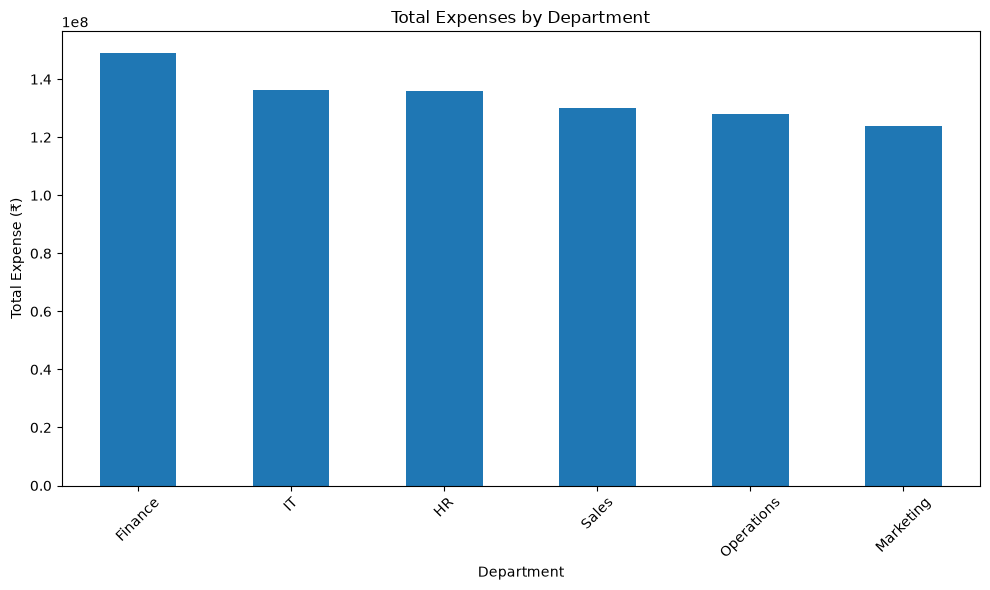

In [32]:
plt.figure(figsize=(10, 6))

department_expense.plot(kind="bar")

plt.title("Total Expenses by Department")
plt.xlabel("Department")
plt.ylabel("Total Expense (₹)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
highest_expense_department = department_expense.idxmax()
highest_department_amount = department_expense.max()

print("Highest Expense Department:", highest_expense_department)
print(f"Total Expense: ₹{highest_department_amount:,.2f}")

Highest Expense Department: Finance
Total Expense: ₹149,028,660.15


In [34]:
region_expense = (
    expense_df
    .groupby("region")["amount"]
    .sum()
    .sort_values(ascending=False)
)

region_expense

region
South      1.667639e+08
Central    1.643966e+08
West       1.618370e+08
North      1.592174e+08
East       1.507839e+08
Name: amount, dtype: float64

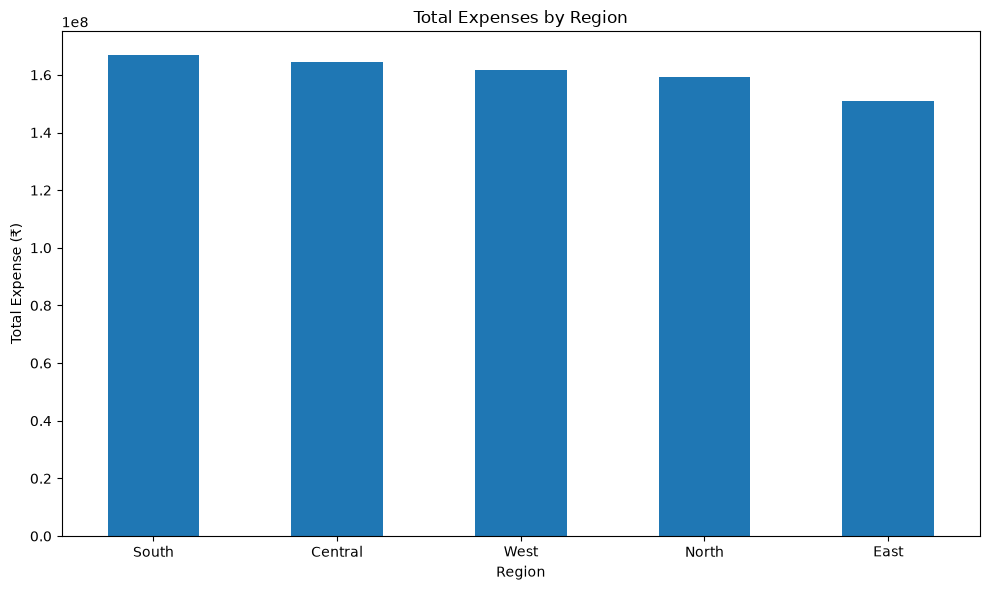

In [35]:
plt.figure(figsize=(10, 6))

region_expense.plot(kind="bar")

plt.title("Total Expenses by Region")
plt.xlabel("Region")
plt.ylabel("Total Expense (₹)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [36]:
highest_expense_region = region_expense.idxmax()
highest_region_amount = region_expense.max()

print("Highest Expense Region:", highest_expense_region)
print(f"Total Expense: ₹{highest_region_amount:,.2f}")

Highest Expense Region: South
Total Expense: ₹166,763,901.29


In [37]:
payment_analysis = (
    df.groupby("payment_method")
      .agg(
          transaction_count=("transaction_id", "count"),
          total_amount=("amount", "sum")
      )
      .sort_values("total_amount", ascending=False)
)

payment_analysis

,transaction_count,total_amount
payment_method,,
Bank Transfer,2044,3.497168e+08
Cash,2076,3.477647e+08
Debit Card,1973,3.410188e+08
Credit Card,1966,3.347528e+08
UPI,1941,3.319015e+08


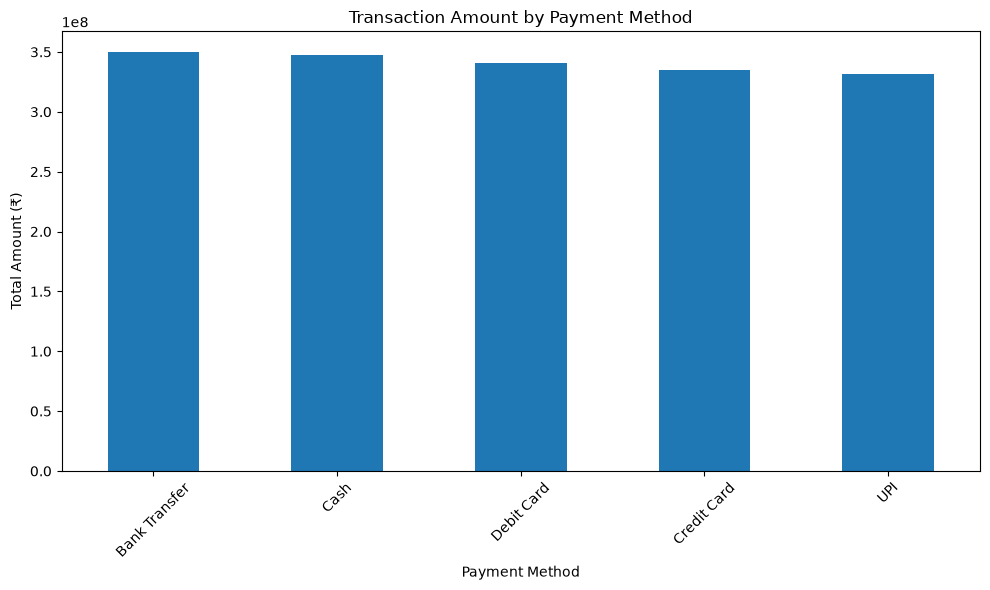

In [38]:
plt.figure(figsize=(10, 6))

payment_analysis["total_amount"].plot(kind="bar")

plt.title("Transaction Amount by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Amount (₹)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
most_used_payment = payment_analysis["transaction_count"].idxmax()
most_used_count = payment_analysis["transaction_count"].max()

print("Most Used Payment Method:", most_used_payment)
print("Number of Transactions:", most_used_count)

Most Used Payment Method: Cash
Number of Transactions: 2076


In [40]:
expense_pivot = pd.pivot_table(
    expense_df,
    values="amount",
    index="department",
    columns="category",
    aggfunc="sum",
    fill_value=0
)

expense_pivot

category,Consulting,Inventory,Marketing,Office Supplies,Rent,Salary,Sales,Technology,Travel,Utilities
department,,,,,,,,,,
Finance,14454227.26,15540384.58,13055284.57,14236912.79,14199519.62,17740452.48,15034160.29,10559134.89,18519435.74,15689147.93
HR,14441609.75,10071873.55,13686894.52,14101505.16,13995147.41,12595105.77,12918207.24,12415534.91,17044279.55,14646798.28
IT,14458338.26,12332713.12,14763686.91,14647580.46,12337875.88,11176648.24,16079798.25,13937103.01,14436741.44,11934734.81
Marketing,16214494.97,12286705.36,11285188.47,11048330.76,13240456.88,11678127.40,11113811.22,12446122.20,11478781.55,13070758.38
Operations,11552111.16,14194423.14,12388880.22,11642285.35,13187012.06,14641172.78,13354636.92,11361867.66,13063783.81,12662812.05
Sales,11959849.38,14323412.85,14683717.84,11987569.91,13412453.50,14025758.31,10840081.14,12446587.83,13857346.98,12499517.56


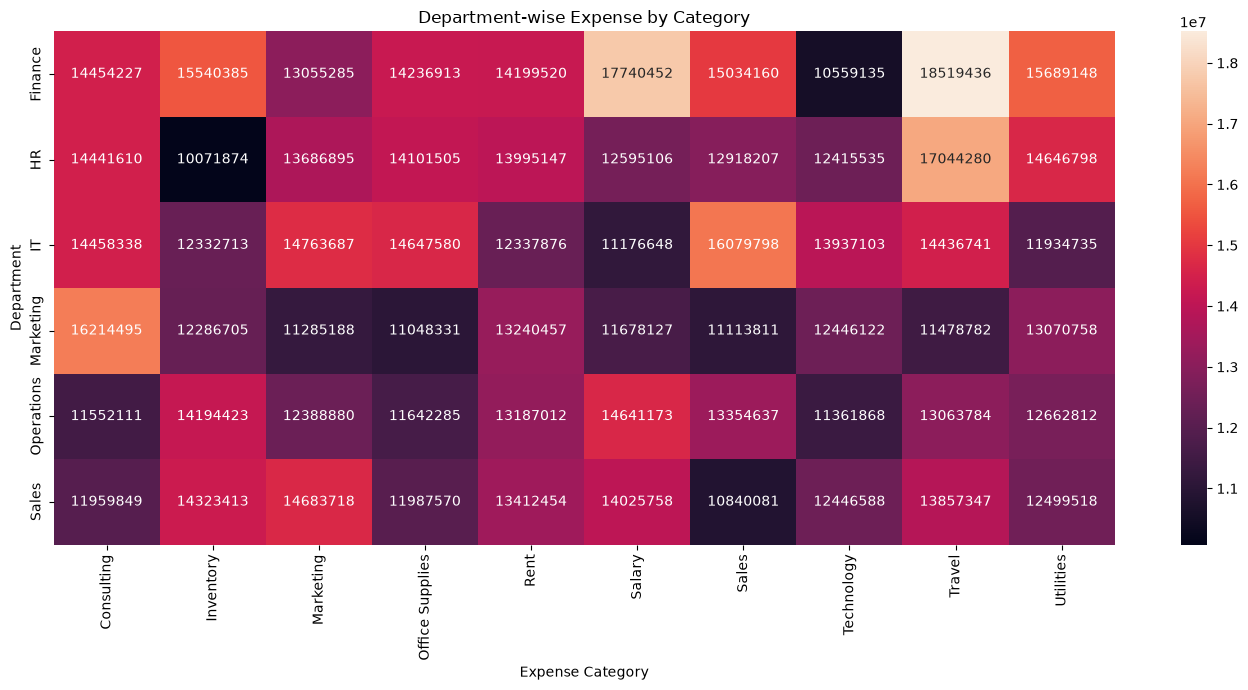

In [41]:
plt.figure(figsize=(14, 7))

sns.heatmap(
    expense_pivot,
    annot=True,
    fmt=".0f"
)

plt.title("Department-wise Expense by Category")
plt.xlabel("Expense Category")
plt.ylabel("Department")

plt.tight_layout()
plt.show()

In [44]:
department_revenue = (
    df[df["transaction_type"] == "Income"]
    .groupby("department")["amount"]
    .sum()
    .sort_values(ascending=False)
)

department_revenue

department
Finance       1.629412e+08
HR            1.545393e+08
IT            1.510757e+08
Sales         1.480660e+08
Operations    1.464809e+08
Marketing     1.390526e+08
Name: amount, dtype: float64

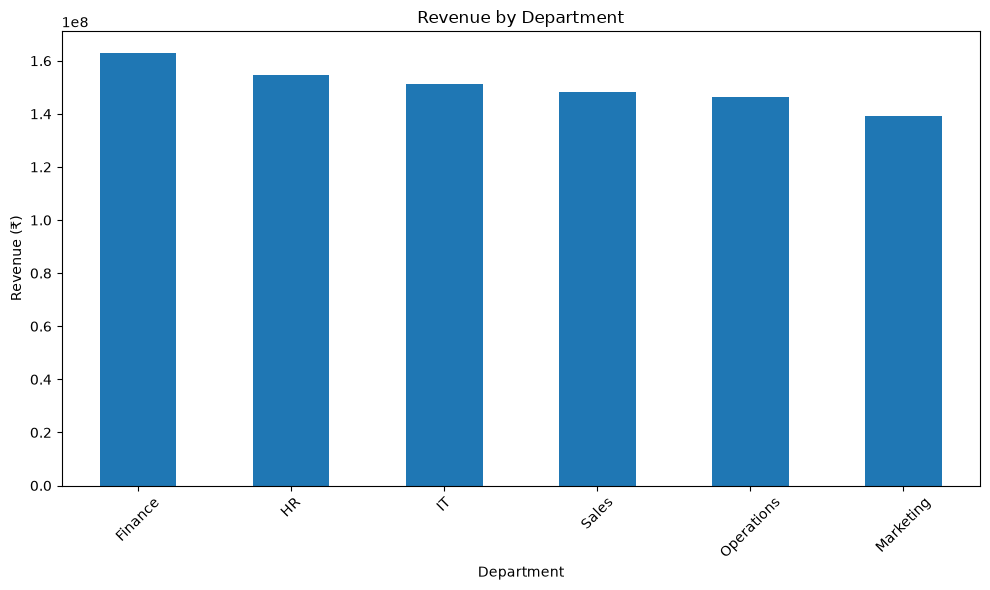

In [45]:
plt.figure(figsize=(10, 6))

department_revenue.plot(kind="bar")

plt.title("Revenue by Department")
plt.xlabel("Department")
plt.ylabel("Revenue (₹)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [46]:
region_revenue = (
    df[df["transaction_type"] == "Income"]
    .groupby("region")["amount"]
    .sum()
    .sort_values(ascending=False)
)

region_revenue

region
East       1.886478e+08
North      1.870333e+08
West       1.863744e+08
Central    1.718812e+08
South      1.682190e+08
Name: amount, dtype: float64

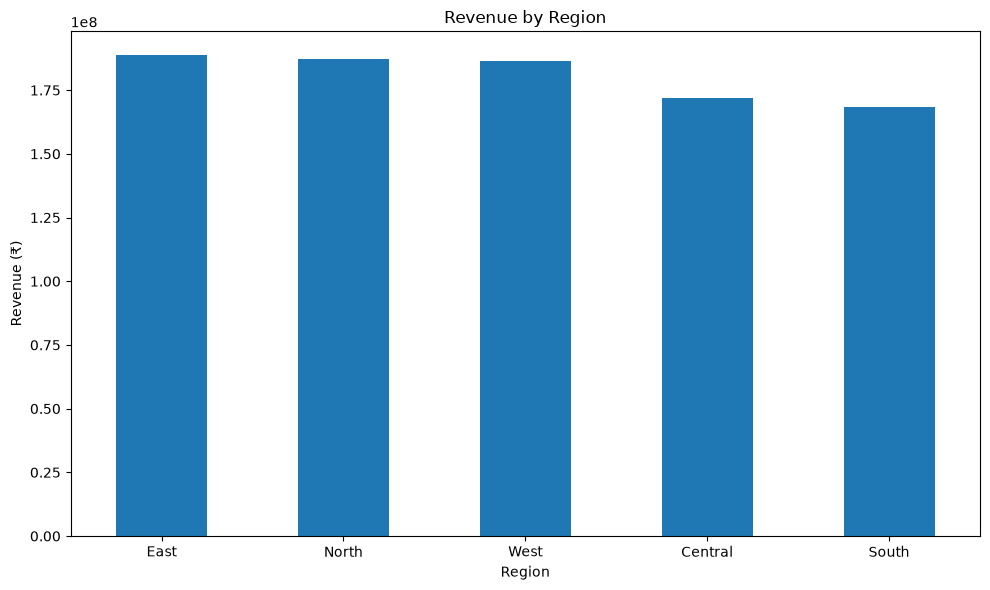

In [47]:
plt.figure(figsize=(10, 6))

region_revenue.plot(kind="bar")

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue (₹)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [48]:

df_clean = df.copy()

df_clean = df_clean.drop_duplicates()

df_clean = df_clean[df_clean["amount"] > 0]

# Ensure transaction date is datetime
df_clean["transaction_date"] = pd.to_datetime(
    df_clean["transaction_date"]
)

print("Data cleaning completed!")
print("Rows after cleaning:", len(df_clean))
print("Columns:", len(df_clean.columns))

Data cleaning completed!
Rows after cleaning: 10000
Columns: 10


In [49]:
from pathlib import Path

output_path = Path("../data/processed/financial_transactions_cleaned.csv")

df_clean.to_csv(output_path, index=False)

print("Cleaned dataset saved successfully!")
print(f"File: {output_path}")

Cleaned dataset saved successfully!
File: ..\data\processed\financial_transactions_cleaned.csv


In [50]:
cleaned_df = pd.read_csv(
    "../data/processed/financial_transactions_cleaned.csv"
)

print("Cleaned file loaded successfully!")
print("Shape:", cleaned_df.shape)

Cleaned file loaded successfully!
Shape: (10000, 10)


In [ ]:
import mysql.connector

connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="aditya@#2211",
    database="ai_finance_controller"
)

if connection.is_connected():
    print("MySQL connection successful!")

connection.close()

MySQL connection successful!


: 